In [1]:
import os
import importlib.util

_origin = importlib.util.find_spec("data.dataset").origin
PROJECT_ROOT = os.path.dirname(os.path.dirname(_origin))
os.chdir(PROJECT_ROOT)
print(PROJECT_ROOT)

/Users/morteza/w/univercity/MLInVision/HW4/q2_homework_code


In [14]:
import time

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt

from data.dataset import train_dataset, val_dataset, test_dataset
from data.data_loader import get_dataloader
from models.model import ViT

from scripts.train import train
from scripts.eval import evaluate
from scripts.main import load_config
import os
from utils.visualization import plot_training_summary

In [3]:
config = load_config("./config/config.yaml")
model_cfg = config["model"]
train_cfg = config["training"]

torch.set_num_threads(os.cpu_count())
device = torch.device("mps")
print(f"Using device: {device}")

EPOCHS = train_cfg["epochs"]

train_loader = get_dataloader(train_dataset, batch_size=train_cfg["batch_size"])
val_loader = get_dataloader(val_dataset, batch_size=train_cfg["batch_size"], shuffle=False)
test_loader = get_dataloader(test_dataset, batch_size=train_cfg["batch_size"], shuffle=False)

IMAGES_DIR = os.path.join("../report/images")
results = []

Using device: mps


In [ ]:
def run_experiment(
    name,
    slug,
    *_,
    image_size=32,
    patch_size=4,
    embedding_dim=128,
    num_heads=8,
    num_layers=4,
    mlp_hidden_dim=128,
    tr_loader=None,
    va_loader=None,
    te_loader=None,
    save=True,
):
    if tr_loader is None:
        tr_loader = train_loader
    if va_loader is None:
        va_loader = val_loader
    if te_loader is None:
        te_loader = test_loader

    print(f"\n===== {name} =====")

    model = ViT(
        image_size=image_size,
        patch_size=patch_size,
        embedding_dim=embedding_dim,
        num_heads=num_heads,
        num_layers=num_layers,
        num_classes=model_cfg["num_classes"],
        mlp_hidden_dim=mlp_hidden_dim,
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(
        model.parameters(),
        lr=train_cfg["lr"],
        weight_decay=train_cfg["weight_decay"],
    )

    start = time.time()
    metadata = train(model, tr_loader, va_loader, optimizer, criterion, device, epochs=EPOCHS)
    duration = time.time() - start

    val_loss, val_acc = metadata[-1]["val_loss"], metadata[-1]["val_acc"]
    print(
        f"[{name}] VAL -> loss={val_loss:.4f} | accuracy={val_acc:.2f}% "
        f"| duration={duration:.1f}s ({EPOCHS} epochs, {duration / EPOCHS:.1f}s/epoch)"
    )

    fig = plot_training_summary(metadata, model_name=name)
    if save:
        os.makedirs(IMAGES_DIR, exist_ok=True)
        fig.savefig(os.path.join(IMAGES_DIR, f"q2-{slug}.png"), bbox_inches="tight")
    plt.show()

    record = {
        "name": name,
        "image_size": image_size,
        "patch_size": patch_size,
        "embedding_dim": embedding_dim,
        "num_heads": num_heads,
        "num_layers": num_layers,
        "mlp_hidden_dim": mlp_hidden_dim if mlp_hidden_dim is not None else embedding_dim * 4,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "duration_s": duration,
        "model": model,
        "criterion": criterion,
        "test_loader": te_loader,
    }
    results.append(record)


===== baseline =====

--- Starting Training loop (5 epochs) ---
Epoch 1 Train Loss: 1.7251 Train Acc: 36.29% Val Loss: 1.7251 Val Acc: 36.29% Duration: 18.0s
Epoch 2 Train Loss: 1.3274 Train Acc: 51.68% Val Loss: 1.3274 Val Acc: 51.68% Duration: 15.6s
Epoch 3 Train Loss: 1.1585 Train Acc: 58.15% Val Loss: 1.1585 Val Acc: 58.15% Duration: 15.7s
Epoch 4 Train Loss: 1.0538 Train Acc: 62.04% Val Loss: 1.0538 Val Acc: 62.04% Duration: 15.8s
Epoch 5 Train Loss: 0.9815 Train Acc: 64.90% Val Loss: 0.9815 Val Acc: 64.90% Duration: 15.8s
[baseline] VAL -> loss=0.9931 | accuracy=65.22% | duration=85.8s (5 epochs, 17.2s/epoch)


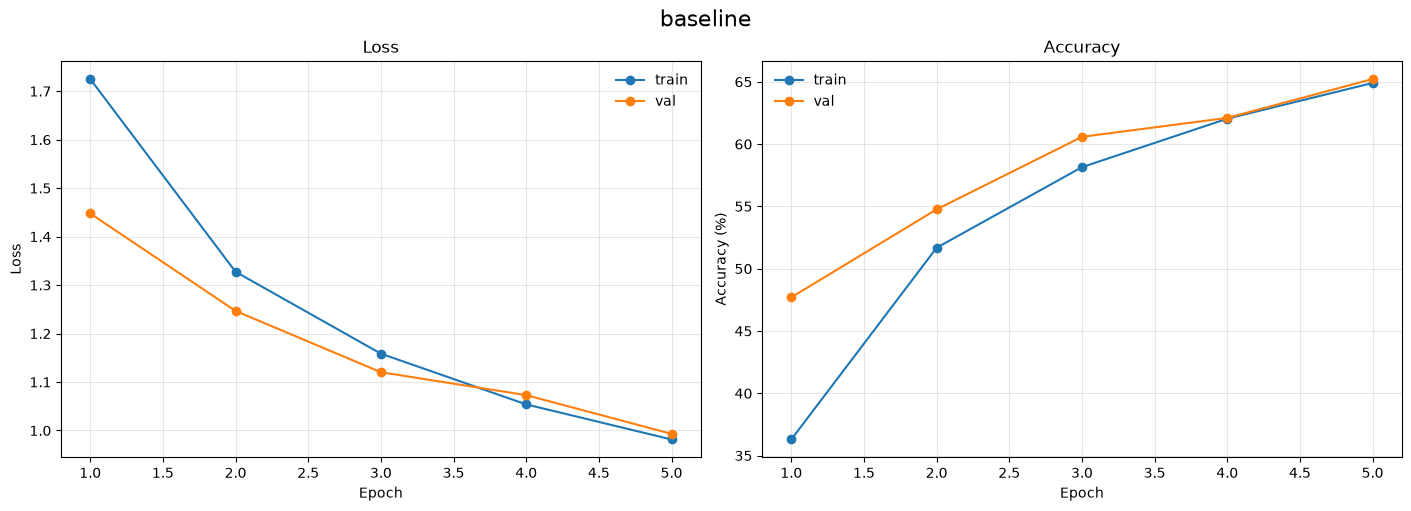

In [5]:
run_experiment(
    "baseline",
    "baseline",
    image_size=model_cfg["image_size"],
    patch_size=model_cfg["patch_size"],
    embedding_dim=model_cfg["embedding_dim"],
    num_heads=model_cfg["num_heads"],
    num_layers=model_cfg["num_layers"],
    mlp_hidden_dim=model_cfg.get("mlp_hidden_dim"),
)


===== embedding=64 =====

--- Starting Training loop (5 epochs) ---
Epoch 1 Train Loss: 1.7217 Train Acc: 36.24% Val Loss: 1.7217 Val Acc: 36.24% Duration: 11.5s
Epoch 2 Train Loss: 1.3663 Train Acc: 50.22% Val Loss: 1.3663 Val Acc: 50.22% Duration: 11.5s
Epoch 3 Train Loss: 1.2216 Train Acc: 55.72% Val Loss: 1.2216 Val Acc: 55.72% Duration: 11.5s
Epoch 4 Train Loss: 1.1265 Train Acc: 59.62% Val Loss: 1.1265 Val Acc: 59.62% Duration: 11.5s
Epoch 5 Train Loss: 1.0554 Train Acc: 62.04% Val Loss: 1.0554 Val Acc: 62.04% Duration: 11.5s
[embedding=64] VAL -> loss=1.0513 | accuracy=62.72% | duration=59.6s (5 epochs, 11.9s/epoch)


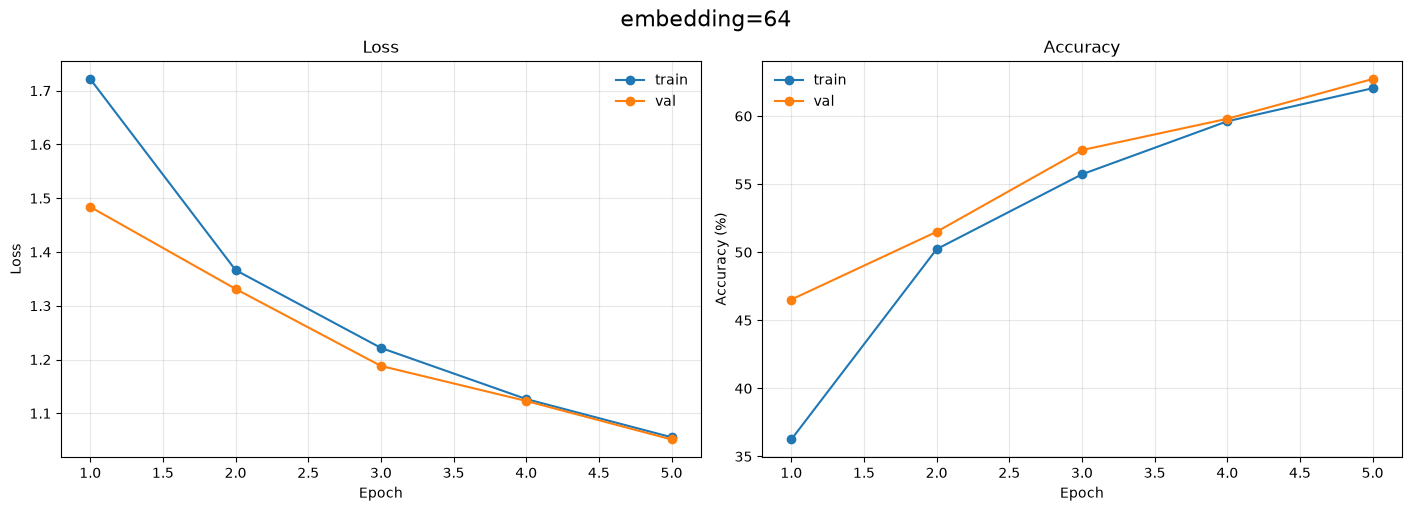

In [6]:
run_experiment("embedding=64", "embed64", embedding_dim=64)


===== embedding=256 =====

--- Starting Training loop (5 epochs) ---
Epoch 1 Train Loss: 1.7438 Train Acc: 35.54% Val Loss: 1.7438 Val Acc: 35.54% Duration: 28.8s
Epoch 2 Train Loss: 1.3526 Train Acc: 50.88% Val Loss: 1.3526 Val Acc: 50.88% Duration: 28.7s
Epoch 3 Train Loss: 1.2006 Train Acc: 56.51% Val Loss: 1.2006 Val Acc: 56.51% Duration: 28.7s
Epoch 4 Train Loss: 1.1057 Train Acc: 60.06% Val Loss: 1.1057 Val Acc: 60.06% Duration: 28.6s
Epoch 5 Train Loss: 1.0513 Train Acc: 61.72% Val Loss: 1.0513 Val Acc: 61.72% Duration: 28.5s
[embedding=256] VAL -> loss=1.0557 | accuracy=62.40% | duration=147.8s (5 epochs, 29.6s/epoch)


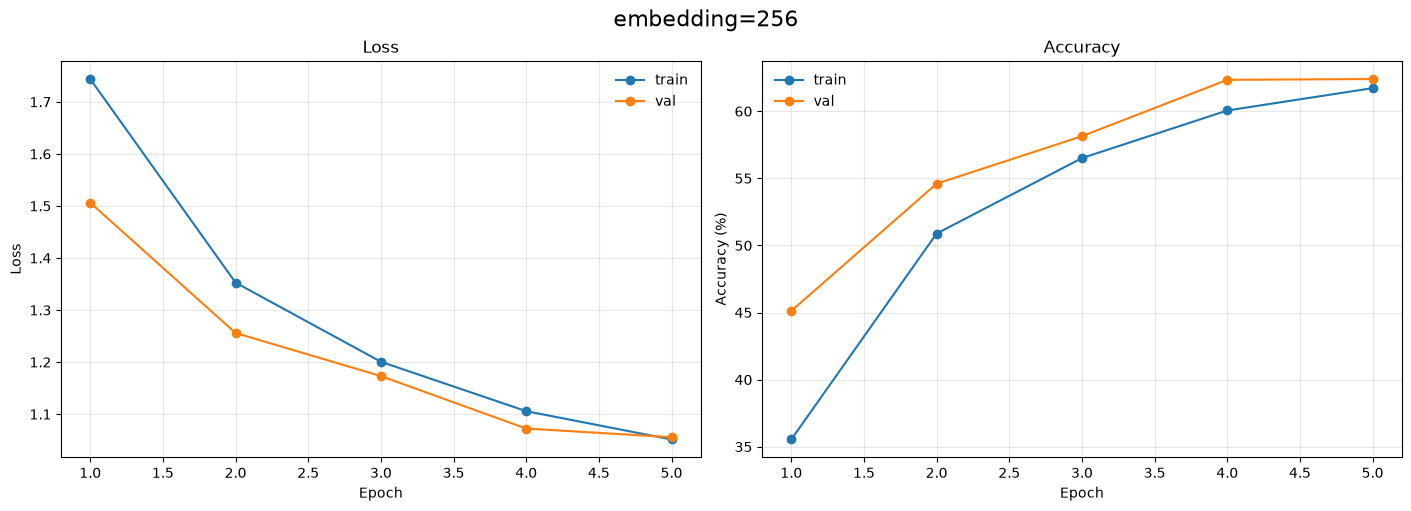

In [7]:
run_experiment("embedding=256", "embed256", embedding_dim=256)

## Number of transformer layers: 2 and 8


===== layers=2 =====

--- Starting Training loop (5 epochs) ---
Epoch 1 Train Loss: 1.6907 Train Acc: 37.38% Val Loss: 1.6907 Val Acc: 37.38% Duration: 8.4s
Epoch 2 Train Loss: 1.3217 Train Acc: 52.09% Val Loss: 1.3217 Val Acc: 52.09% Duration: 8.3s
Epoch 3 Train Loss: 1.1857 Train Acc: 57.05% Val Loss: 1.1857 Val Acc: 57.05% Duration: 8.3s
Epoch 4 Train Loss: 1.0979 Train Acc: 60.40% Val Loss: 1.0979 Val Acc: 60.40% Duration: 8.3s
Epoch 5 Train Loss: 1.0315 Train Acc: 62.68% Val Loss: 1.0315 Val Acc: 62.68% Duration: 8.3s
[layers=2] VAL -> loss=1.0180 | accuracy=63.60% | duration=43.2s (5 epochs, 8.6s/epoch)


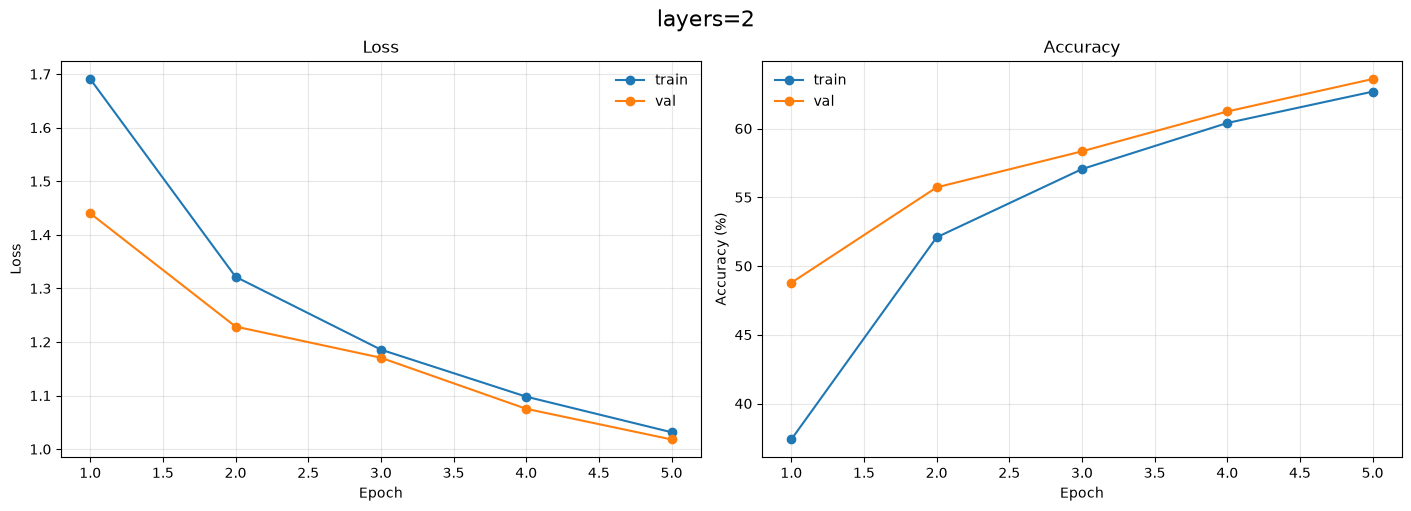

In [8]:
run_experiment("layers=2", "layers2", num_layers=2)


===== layers=8 =====

--- Starting Training loop (5 epochs) ---
Epoch 1 Train Loss: 1.7514 Train Acc: 35.07% Val Loss: 1.7514 Val Acc: 35.07% Duration: 30.4s
Epoch 2 Train Loss: 1.3744 Train Acc: 49.82% Val Loss: 1.3744 Val Acc: 49.82% Duration: 30.4s
Epoch 3 Train Loss: 1.1905 Train Acc: 56.64% Val Loss: 1.1905 Val Acc: 56.64% Duration: 30.1s
Epoch 4 Train Loss: 1.0847 Train Acc: 61.18% Val Loss: 1.0847 Val Acc: 61.18% Duration: 30.3s
Epoch 5 Train Loss: 0.9974 Train Acc: 64.12% Val Loss: 0.9974 Val Acc: 64.12% Duration: 30.3s
[layers=8] VAL -> loss=1.0041 | accuracy=63.98% | duration=156.6s (5 epochs, 31.3s/epoch)


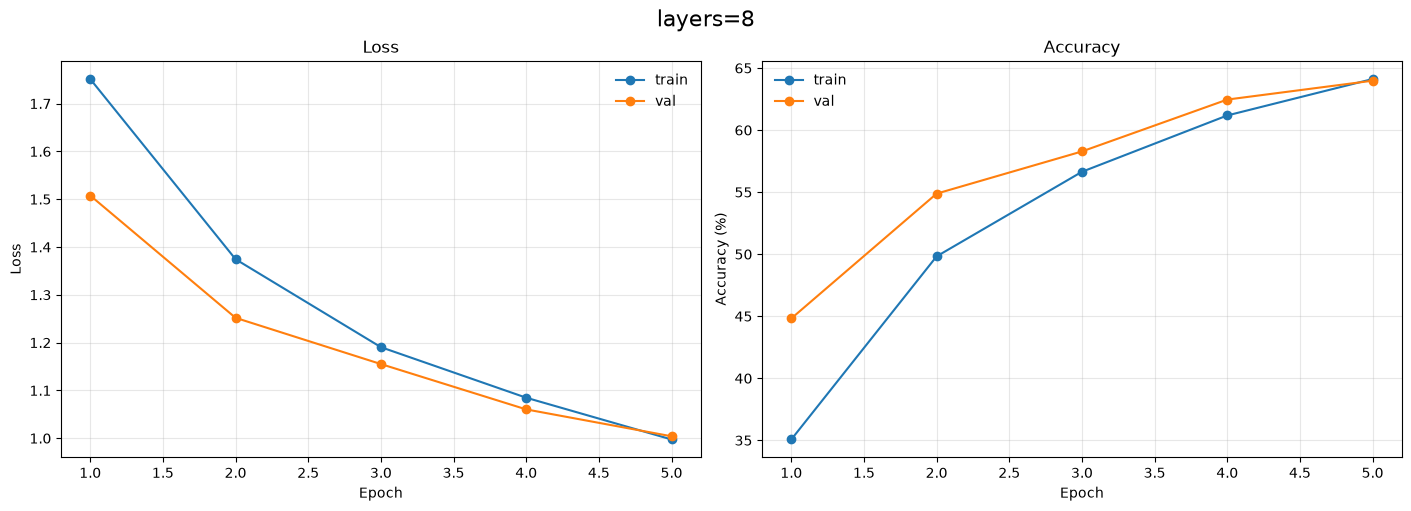

In [9]:
run_experiment("layers=8", "layers8", num_layers=8)


===== patch=2x2 =====

--- Starting Training loop (5 epochs) ---
Epoch 1 Train Loss: 1.7469 Train Acc: 35.25% Val Loss: 1.7469 Val Acc: 35.25% Duration: 122.8s
Epoch 2 Train Loss: 1.3525 Train Acc: 50.79% Val Loss: 1.3525 Val Acc: 50.79% Duration: 335.3s
Epoch 3 Train Loss: 1.1520 Train Acc: 58.58% Val Loss: 1.1520 Val Acc: 58.58% Duration: 129.4s
Epoch 4 Train Loss: 1.0495 Train Acc: 62.44% Val Loss: 1.0495 Val Acc: 62.44% Duration: 122.6s
Epoch 5 Train Loss: 0.9706 Train Acc: 65.39% Val Loss: 0.9706 Val Acc: 65.39% Duration: 123.0s
[patch=2x2] VAL -> loss=0.9817 | accuracy=65.26% | duration=860.4s (5 epochs, 172.1s/epoch)


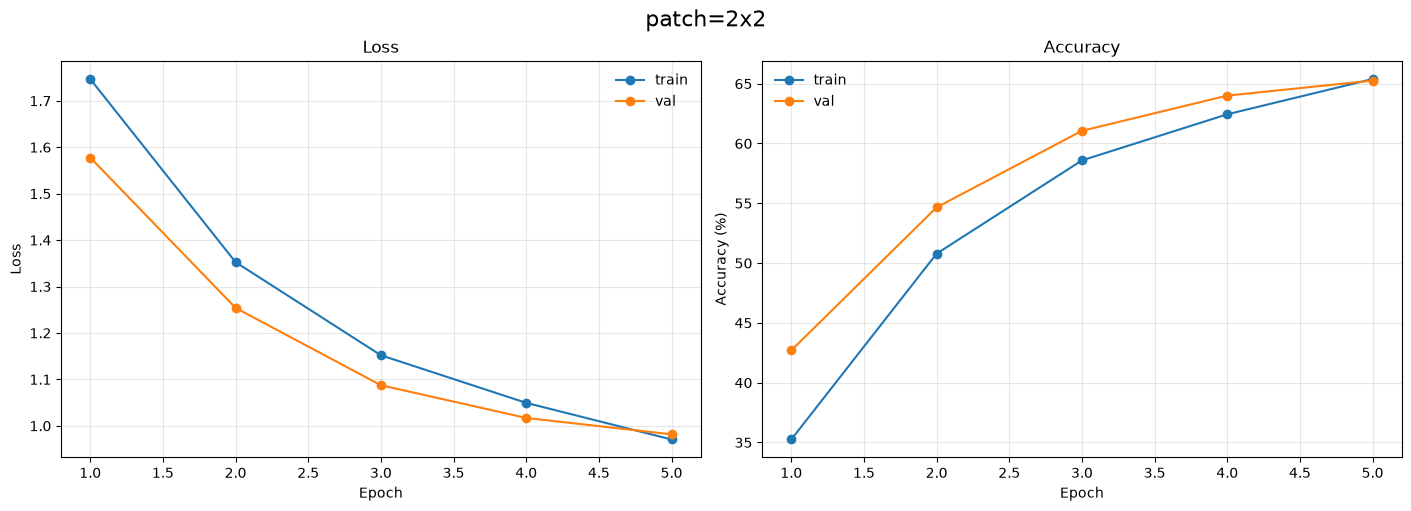

In [10]:
run_experiment("patch=2x2", "patch2", patch_size=2)


===== patch=8x8 =====

--- Starting Training loop (5 epochs) ---
Epoch 1 Train Loss: 1.7870 Train Acc: 34.37% Val Loss: 1.7870 Val Acc: 34.37% Duration: 4.6s
Epoch 2 Train Loss: 1.5098 Train Acc: 44.93% Val Loss: 1.5098 Val Acc: 44.93% Duration: 3.8s
Epoch 3 Train Loss: 1.3406 Train Acc: 51.69% Val Loss: 1.3406 Val Acc: 51.69% Duration: 3.9s
Epoch 4 Train Loss: 1.2293 Train Acc: 55.72% Val Loss: 1.2293 Val Acc: 55.72% Duration: 3.8s
Epoch 5 Train Loss: 1.1596 Train Acc: 58.10% Val Loss: 1.1596 Val Acc: 58.10% Duration: 3.8s
[patch=8x8] VAL -> loss=1.1791 | accuracy=57.00% | duration=20.5s (5 epochs, 4.1s/epoch)


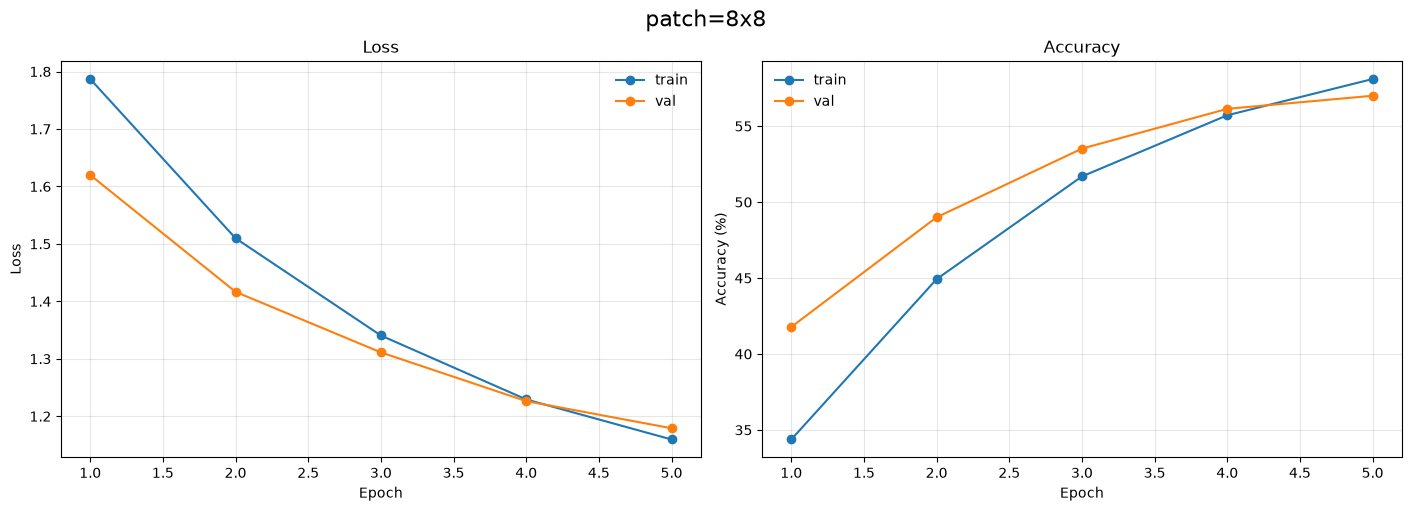

In [11]:
run_experiment("patch=8x8", "patch8", patch_size=8)


===== image=64x64 =====

--- Starting Training loop (5 epochs) ---
Epoch 1 Train Loss: 1.7217 Train Acc: 36.22% Val Loss: 1.7217 Val Acc: 36.22% Duration: 130.9s
Epoch 2 Train Loss: 1.3070 Train Acc: 52.29% Val Loss: 1.3070 Val Acc: 52.29% Duration: 125.7s
Epoch 3 Train Loss: 1.1433 Train Acc: 58.44% Val Loss: 1.1433 Val Acc: 58.44% Duration: 123.6s
Epoch 4 Train Loss: 1.0273 Train Acc: 62.91% Val Loss: 1.0273 Val Acc: 62.91% Duration: 124.6s
Epoch 5 Train Loss: 0.9606 Train Acc: 65.52% Val Loss: 0.9606 Val Acc: 65.52% Duration: 166.8s
[image=64x64] VAL -> loss=0.9783 | accuracy=64.76% | duration=702.3s (5 epochs, 140.5s/epoch)


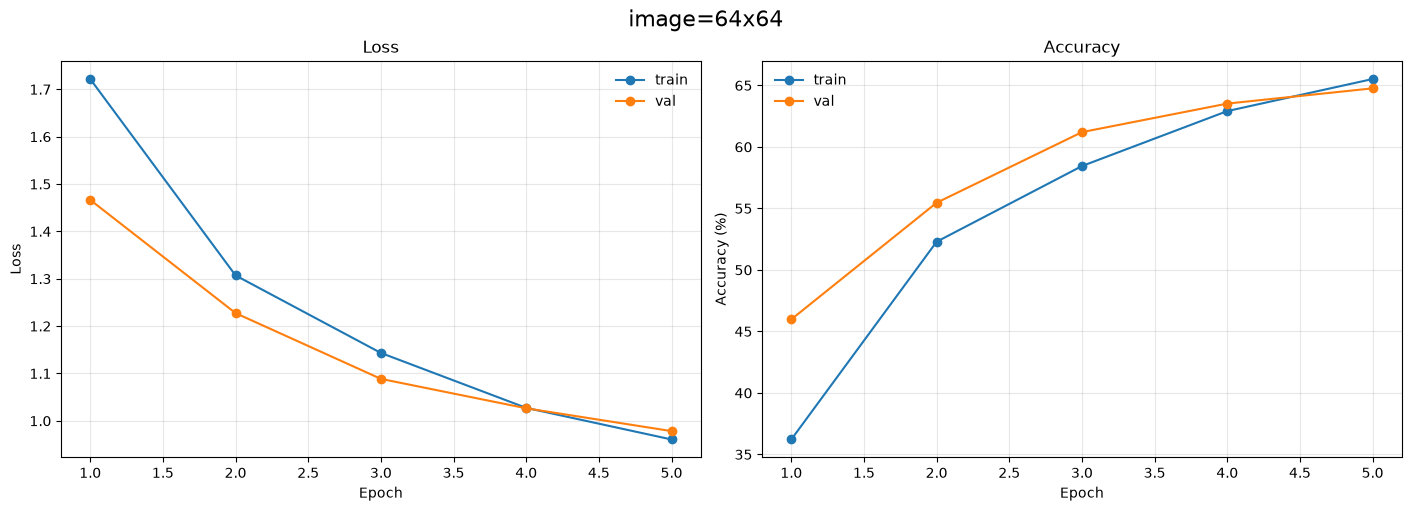

In [12]:
from torch.utils.data import Subset
from data.dataset import TRAIN_INDICES, VAL_INDICES

_mean = (0.4914, 0.4822, 0.4465)
_std = (0.2023, 0.1994, 0.2010)
_tf_train64 = T.Compose([
    T.Resize((64, 64)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(_mean, _std),
])
_tf_eval64 = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor(),
    T.Normalize(_mean, _std),
])

_data_root = os.path.join(PROJECT_ROOT, "data")
# Reuse the exact train/val split from data.dataset, but at 64x64.
# Val/test use the eval transform (no random flip).
_train_full64 = torchvision.datasets.CIFAR10(_data_root, train=True, download=True, transform=_tf_train64)
_val_full64 = torchvision.datasets.CIFAR10(_data_root, train=True, download=True, transform=_tf_eval64)
test_ds64 = torchvision.datasets.CIFAR10(_data_root, train=False, download=True, transform=_tf_eval64)

train_ds64 = Subset(_train_full64, TRAIN_INDICES)
val_ds64 = Subset(_val_full64, VAL_INDICES)

train_loader64 = get_dataloader(train_ds64, batch_size=train_cfg["batch_size"])
val_loader64 = get_dataloader(val_ds64, batch_size=train_cfg["batch_size"], shuffle=False)
test_loader64 = get_dataloader(test_ds64, batch_size=train_cfg["batch_size"], shuffle=False)

run_experiment(
    "image=64x64",
    "img64",
    image_size=64,
    tr_loader=train_loader64,
    va_loader=val_loader64,
    te_loader=test_loader64,
)

In [13]:
# Final report: the test set is touched only here, once per trained model.
print("Final report -- evaluating each trained model on the held-out TEST set\n")
for r in results:
    test_loss, test_acc = evaluate(r["model"], r["test_loader"], device, r["criterion"])
    r["test_loss"] = test_loss
    r["test_acc"] = test_acc

header = (
    f"{'experiment':<48} {'embed':>6} {'heads':>6} {'layers':>7} {'mlp_h':>7} "
    f"{'patch':>6} {'img':>5} {'val_acc%':>9} {'test_loss':>10} {'test_acc%':>10} {'dur(s)':>8}"
)
print(header)
print("-" * len(header))
for r in results:
    print(
        f"{r['name']:<48} {r['embedding_dim']:>6} {r['num_heads']:>6} {r['num_layers']:>7} "
        f"{r['mlp_hidden_dim']:>7} {r['patch_size']:>6} {r['image_size']:>5} "
        f"{r['val_acc']:>9.2f} {r['test_loss']:>10.4f} {r['test_acc']:>10.2f} {r['duration_s']:>8.1f}"
    )

Final report -- evaluating each trained model on the held-out TEST set

experiment                                        embed  heads  layers   mlp_h  patch   img  val_acc%  test_loss  test_acc%   dur(s)
------------------------------------------------------------------------------------------------------------------------------------
baseline                                            128      8       4     128      4    32     65.22     1.0353      62.53     85.8
embedding=64                                         64      8       4     128      4    32     62.72     1.0794      60.84     59.6
embedding=256                                       256      8       4     128      4    32     62.40     1.0545      62.10    147.8
layers=2                                            128      8       2     128      4    32     63.60     1.0428      62.37     43.2
layers=8                                            128      8       8     128      4    32     63.98     1.0407      62.78    156